In [1]:
import pandas as pd
df = pd.read_csv('HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [2]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [3]:
moyenne = df['EngagementSurvey'].mean()
mediane = df['EngagementSurvey'].median()
ecart_type = df['EngagementSurvey'].std()

print(f"Moyenne : {moyenne:.2f} heures")
print(f"Médiane : {mediane:.2f} heures")
print(f"Écart-type : {ecart_type:.2f} heures")

Moyenne : 4.11 heures
Médiane : 4.28 heures
Écart-type : 0.79 heures


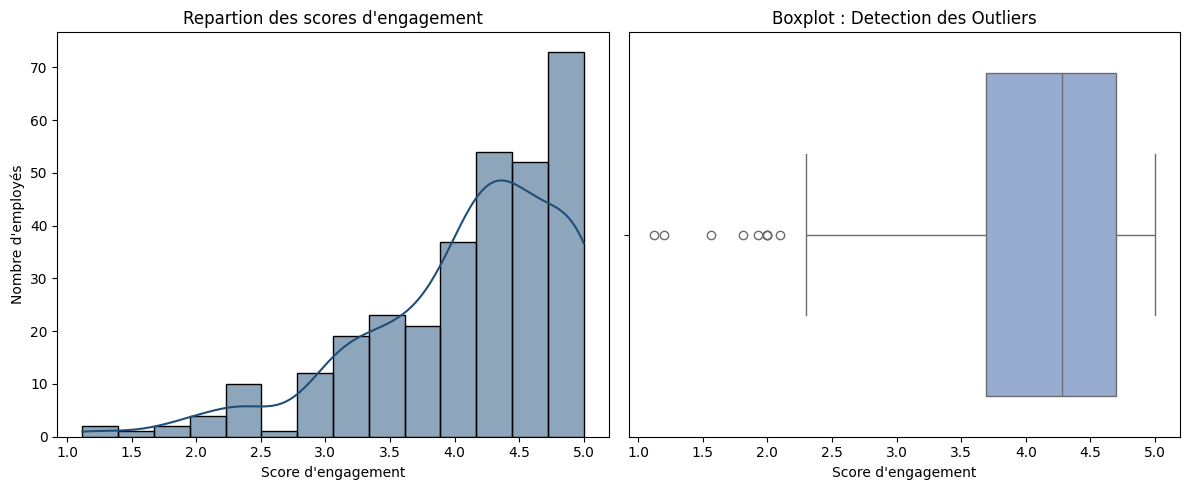

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.histplot(df['EngagementSurvey'], kde=True, color='#1F4E78')
plt.title("Repartion des scores d'engagement")
plt.xlabel("Score d'engagement")
plt.ylabel("Nombre d'employés")

plt.subplot(1,2,2)
sns.boxplot(x=df['EngagementSurvey'], color='#8EA9DB')
plt.title("Boxplot : Detection des Outliers")
plt.xlabel("Score d'engagement")

plt.tight_layout()
plt.show()

In [7]:
colonne_etudiee = 'EngagementSurvey'
Q1 = df[colonne_etudiee].quantile(0.25)
Q3 = df[colonne_etudiee].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print(f"--analyse des outliers pour {colonne_etudiee}--")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"borne inf: {borne_inf}")
print(f"borne sup: {borne_sup}")
print


--analyse des outliers pour EngagementSurvey--
Q1: 3.69
Q3: 4.7
IQR: 1.0100000000000002
borne inf: 2.175
borne sup: 6.215000000000001


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [11]:
colonne = 'EngagementSurvey'
limite_basse = 2.175
limite_haute = 6.215
outliers = df[(df[colonne] < limite_basse) | (df[colonne] > limite_haute)]
print(f"limites de normalité : de {limite_basse:.3f} à {limite_haute:.3f}")
print(f"nombres d'outliers détectés : {len(outliers)}")

colonne_a_afficher = ['EmpID', 'DeptID', 'PerformanceScore', 'EngagementSurvey']
print("\nProfil des employés avec un engagment anormalement bas :")
print(outliers[colonne_a_afficher])

limites de normalité : de 2.175 à 6.215
nombres d'outliers détectés : 9

Profil des employés avec un engagment anormalement bas :
     EmpID  DeptID   PerformanceScore  EngagementSurvey
23   10294       5  Needs Improvement              2.00
53   10292       5  Needs Improvement              2.00
67   10306       6                PIP              1.93
69   10310       5                PIP              1.12
86   10290       4  Needs Improvement              2.10
90   10308       5                PIP              1.56
91   10309       3                PIP              1.20
95   10305       6                PIP              2.00
267  10307       6                PIP              1.81


L'analyse de la distribution des scores d'engagement (EngagementSurvey) révèle que la majorité des employés (les 50% centraux) ont un score compris entre 3.69 et 4.70 sur 5. >
En appliquant la méthode de l'écart interquartile (IQR), la limite basse de normalité a été fixée à 2.175. L'algorithme a permis d'identifier des valeurs aberrantes (outliers) dont le score descend jusqu'à 1.12. Étant donné que la limite haute théorique (6.215) dépasse le score maximum possible (5.0), tous nos outliers se situent vers le bas.

Facteur d'amélioration pour les RH : Ces employés atypiques montrent un niveau de désengagement critique. Il est nécessaire de croiser ces profils avec leur département (DeptID) ou leur manager (ManagerID) pour voir si ce mal-être est isolé ou s'il provient d'une équipe en particulier